<a href="https://colab.research.google.com/github/ultimatepin/card_recognizer/blob/main/notebooks/03_automatic%20crop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## v2

colab is a cloud computer

! means a normal terminal command

In [16]:
%cd /content

!rm -rf card_recognizer
!git clone https://github.com/ultimatepin/card_recognizer.git

%cd /content/card_recognizer

!pip -q install transformers pillow

/content
Cloning into 'card_recognizer'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 95 (delta 32), reused 33 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 14.28 MiB | 31.72 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/card_recognizer


In [17]:
import os
import torch

from PIL import Image
from transformers import AutoProcessor, CLIPVisionModelWithProjection

MODEL_NAME = "openai/clip-vit-base-patch32"

# processor converts image to processable format
processor = AutoProcessor.from_pretrained(MODEL_NAME)

# transformer and outputs embedding
model = CLIPVisionModelWithProjection.from_pretrained(MODEL_NAME)

# eval mode not train mode
model.eval()

def get_embedding(image_path):
    image = Image.open(image_path).convert("RGB")

    # convert to pytorch tensor(pixel_values) to input model
    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    # not training the model, faster calc
    with torch.inference_mode():
        # pixel_values -> bunch of outputs
        output = model(**inputs)

    # embedding extraction
    embedding = output.image_embeds

    # Normalize the vector
    embedding = embedding / embedding.norm(dim=-1, keepdim=True)

    return embedding

card_folder = "cards"

card_embeddings = {}

for filename in os.listdir(card_folder):
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):
        path = os.path.join(card_folder, filename)

        card_embeddings[filename] = get_embedding(path)

print(f"Loaded {len(card_embeddings)} cards.")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.embeddings.position_embedding.weight              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0

Loaded 12 cards.


## Cropping

In [18]:
!pip -q install opencv-python-headless

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [19]:
def order_points(points):
    points = np.array(points, dtype="float32")

    ordered = np.zeros((4, 2), dtype="float32")

    s = points.sum(axis=1)
    diff = np.diff(points, axis=1).reshape(-1)

    ordered[0] = points[np.argmin(s)]      # top-left
    ordered[1] = points[np.argmin(diff)]   # top-right
    ordered[2] = points[np.argmax(s)]      # bottom-right
    ordered[3] = points[np.argmax(diff)]   # bottom-left

    return ordered

In [20]:
def auto_crop_card(image_path):
    image = cv2.imread(image_path)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contours = sorted(
        contours,
        key=cv2.contourArea,
        reverse=True
    )

    card_corners = None

    for contour in contours:
        perimeter = cv2.arcLength(contour, True)

        approx = cv2.approxPolyDP(
            contour,
            0.02 * perimeter,
            True
        )

        if len(approx) == 4:
            card_corners = approx.reshape(4, 2)
            break

    if card_corners is None:
        return None

    src = order_points(card_corners)

    width = 750
    height = 1050

    dst = np.array([
        [0, 0],
        [width - 1, 0],
        [width - 1, height - 1],
        [0, height - 1]
    ], dtype="float32")

    transform = cv2.getPerspectiveTransform(src, dst)

    cropped = cv2.warpPerspective(
        image,
        transform,
        (width, height)
    )

    return cropped

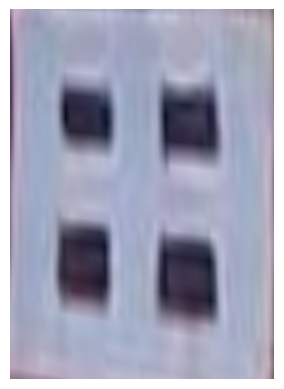

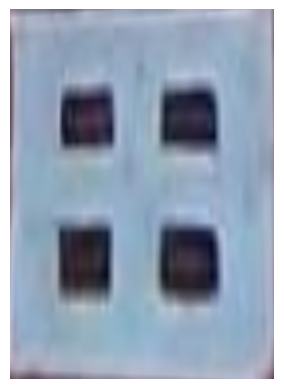

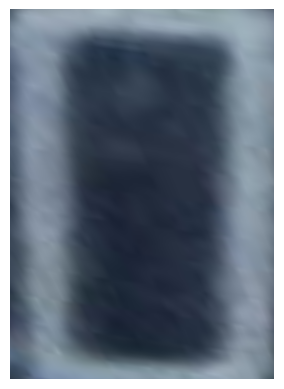

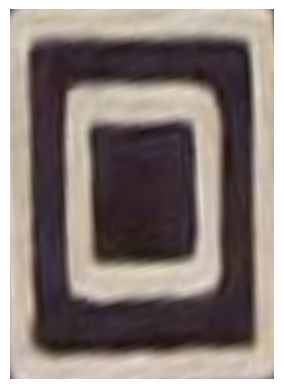

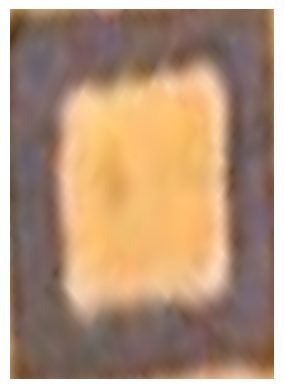

In [21]:
tests = [
    "queries/OGN-249_1.jpg",
    "queries/OGN-249_2.jpg",
    "queries/OGN-253_1.jpg",
    "queries/OGN-255_1.jpg",
    "queries/OGN-265_1.jpg"
]

for card in tests:
  cropped = auto_crop_card(card)

  if cropped is not None:
      plt.figure()
      plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
      plt.axis("off")
  else:
      print("Card not detected")